- By Nabankur Ray

**Background**

Cirrhosis results from prolonged liver damage, leading to extensive scarring, often due to conditions like hepatitis or chronic alcohol consumption. The data provided is a subset sourced from a Mayo Clinic study on primary biliary cirrhosis (PBC) of the liver carried out from 1974 to 1984.

This is a dataset to develop and validate machine learning algorithms for predicting the
survival status of the collected patients. There are 418 patients in the data set, and each
patient has 17 collected features. The aim of this task is to utilize 17 clinical features for
predicting survival state of patients with liver cirrhosis. The survival states include 0 = D
(death), 1 = C (censored), 2 = CL (censored due to liver transplantation)

**Key goals include:**

* Handling missing values and preprocessing the dataset for modeling.

* Identifying and encoding categorical variables appropriately.

* Building and comparing multiple supervised machine learning models to predict patient survival status.

* Evaluating model performance using suitable metrics to assess accuracy and generalization.

* Investigating whether class imbalance affects model performance and applying methods to address it if needed.

* Recommending the most suitable model for clinical decision support based on predictive accuracy and robustness.

# Import necessary libraries

In [169]:
import pandas as pd      # For data manipulation and analysis
import numpy as np        # For numerical computations and array operations
import matplotlib.pyplot as plt        # For data visualization (basic plotting like line, bar, scatter plots)
import seaborn as sns                  # For advanced data visualization (especially statistical plots)
from sklearn.model_selection import train_test_split  # For splitting data into training/testing sets
from sklearn.impute import SimpleImputer  # For handling missing values
from sklearn.preprocessing import OneHotEncoder  # For encoding categorical variables

In [170]:
# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x) # To display floating-point numbers with 3 decimal places

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

In [171]:
# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Loading the Data sets

In [172]:
# Loading the Datasets from the Drive
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [173]:
# Loading the Microclimate Sensor Data
data = pd.read_csv('/content/drive/My Drive/cirrhosis.csv')
data.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.500,261.000,2.600,156.000,1718.000,137.950,172.000,190.000,12.200,4.000
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.100,302.000,4.140,54.000,7394.800,113.520,88.000,221.000,10.600,3.000
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.400,176.000,3.480,210.000,516.000,96.100,55.000,151.000,12.000,4.000
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.800,244.000,2.540,64.000,6121.800,60.630,92.000,183.000,10.300,4.000
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.400,279.000,3.530,143.000,671.000,113.150,72.000,136.000,10.900,3.000


# Data Understanding

In [174]:
# Checking the shape of the data
data.shape

(418, 20)

In [175]:
# Checking the structure and data type of the given data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

*Observations*

* There are **418 rows** and **20 Columns** are present in the given datasets.

* It can be observed that some columns have less entries (less than 418 rows) which indicates that **there are few missing values in the given dataset.**

* There are attributes of different types (int, float & object) in the dataset.

* There are 13 numerical columns (float) in the data and 7 categorical columns (object).

Statistical summary of the dataset

In [176]:
# Numerical summary statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,418.000,209.500,120.810,1.000,105.250,209.500,313.750,418.000
N_Days,418.000,1917.782,1104.673,41.000,1092.750,1730.000,2613.500,4795.000
Age,418.000,18533.352,3815.845,9598.000,15644.500,18628.000,21272.500,28650.000
Bilirubin,418.000,3.221,4.408,0.300,0.800,1.400,3.400,28.000
Cholesterol,284.000,369.511,231.945,120.000,249.500,309.500,400.000,1775.000
Albumin,418.000,3.497,0.425,1.960,3.243,3.530,3.770,4.640
Copper,310.000,97.648,85.614,4.000,41.250,73.000,123.000,588.000
Alk_Phos,312.000,1982.656,2140.389,289.000,871.500,1259.000,1980.000,13862.400
SGOT,312.000,122.556,56.700,26.350,80.600,114.700,151.900,457.250
Tryglicerides,282.000,124.702,65.149,33.000,84.250,108.000,151.000,598.000


In [177]:
# Categorical summary statistics
data.describe(include='object').T

,count,unique,top,freq
Status,418,3,C,232
Drug,312,2,D-penicillamine,158
Sex,418,2,F,374
Ascites,312,2,N,288
Hepatomegaly,312,2,Y,160
Spiders,312,2,N,222
Edema,418,3,N,354


In [178]:
# checking the number of unique values
data.nunique()

,0
ID,418
N_Days,399
Status,3
Drug,2
Age,344
Sex,2
Ascites,2
Hepatomegaly,2
Spiders,2
Edema,3


In [179]:
# Viewing the unique elements in categorical columns
for col in data.select_dtypes(include='object').columns:
  print(f'{col}: {data[col].unique()}')


Status: ['D' 'C' 'CL']
Drug: ['D-penicillamine' 'Placebo' nan]
Sex: ['F' 'M']
Ascites: ['Y' 'N' nan]
Hepatomegaly: ['Y' 'N' nan]
Spiders: ['Y' 'N' nan]
Edema: ['Y' 'N' 'S']


# Checking for Missing Values

In [180]:
# checking for the duplicate values
data.duplicated().sum()

np.int64(0)

In [181]:
# Printing the No. of Missing Values in sorted order
missing_value_count = data.isnull().sum()
missing_value_count_sorted = missing_value_count.sort_values(ascending=False)
missing_value_count_sorted

,0
Tryglicerides,136
Cholesterol,134
Copper,108
Drug,106
Alk_Phos,106
SGOT,106
Spiders,106
Hepatomegaly,106
Ascites,106
Platelets,11


In [182]:
# Calculate the percentage of missing values in each column
missing_percentage = (data.isnull().sum() / len(data)) * 100

# Sort the columns by the percentage of missing values in descending order
missing_percentage_sorted = missing_percentage.sort_values(ascending=False)

# Print the sorted percentage of missing values
missing_percentage_sorted

,0
Tryglicerides,32.536
Cholesterol,32.057
Copper,25.837
Drug,25.359
Alk_Phos,25.359
SGOT,25.359
Spiders,25.359
Hepatomegaly,25.359
Ascites,25.359
Platelets,2.632


In [183]:
# Checking the total number of missing values
total_missing = missing_value_count.sum()

print(f"Total number of missing values: {total_missing}")

Total number of missing values: 1033


When data is skewed (not symmetric), the mean gets pulled in the direction of the skew due to extreme values (outliers). Median is robust to outliers, so it's a better central estimate for skewed distributions.

Used median for skewed numeric data, mean for normally distributed numeric data, & mode for categorical variables.

In [184]:
# Filling missing values using Mean or Median for numeric columns and Mode for categorical columns

missing_counts = data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

print("\nImputing Missing Values\n")
impute_values = {}

# Define numeric and categorical columns
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = data.select_dtypes(include='object').columns

# Separate numeric and categorical columns that have missing values
numeric_cols_with_missing = data[numeric_cols].columns[data[numeric_cols].isnull().any()].tolist()
categorical_cols_with_missing = data[categorical_cols].columns[data[categorical_cols].isnull().any()].tolist()

# Impute numeric columns
for col in numeric_cols_with_missing:
    # Choose median if data is skewed, else mean
    if data[col].skew() > 1 or data[col].skew() < -1:
        replacement = data[col].median()
        method = 'median'
    else:
        replacement = data[col].mean()
        method = 'mean'

    data[col].fillna(replacement, inplace=True)
    impute_values[col] = (method, replacement)

# Impute categorical columns with mode
for col in categorical_cols_with_missing:
    replacement = data[col].mode()[0]
    method = 'mode'
    data[col].fillna(replacement, inplace=True)
    impute_values[col] = (method, replacement)


# Display replacement values
for col, (method, value) in impute_values.items():
    if method in ['mean', 'median']:
        print(f"{col}: Filled using {method.upper()} = {value:.3f}")
    else:
        print(f"{col}: Filled using {method.upper()} = {value}")


Imputing Missing Values

Cholesterol: Filled using MEDIAN = 309.500
Copper: Filled using MEDIAN = 73.000
Alk_Phos: Filled using MEDIAN = 1259.000
SGOT: Filled using MEDIAN = 114.700
Tryglicerides: Filled using MEDIAN = 108.000
Platelets: Filled using MEAN = 257.025
Prothrombin: Filled using MEDIAN = 10.600
Stage: Filled using MEAN = 3.024
Drug: Filled using MODE = D-penicillamine
Ascites: Filled using MODE = N
Hepatomegaly: Filled using MODE = Y
Spiders: Filled using MODE = N


In [185]:
# Checking for missing Values
data.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0


In [186]:
# Viewing the unique elements in categorical columns
for col in data.select_dtypes(include='object').columns:
  print(f'{col}: {data[col].unique()}')

Status: ['D' 'C' 'CL']
Drug: ['D-penicillamine' 'Placebo']
Sex: ['F' 'M']
Ascites: ['Y' 'N']
Hepatomegaly: ['Y' 'N']
Spiders: ['Y' 'N']
Edema: ['Y' 'N' 'S']


In [187]:
data.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.500,261.000,2.600,156.000,1718.000,137.950,172.000,190.000,12.200,4.000
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.100,302.000,4.140,54.000,7394.800,113.520,88.000,221.000,10.600,3.000
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.400,176.000,3.480,210.000,516.000,96.100,55.000,151.000,12.000,4.000
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.800,244.000,2.540,64.000,6121.800,60.630,92.000,183.000,10.300,4.000
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.400,279.000,3.530,143.000,671.000,113.150,72.000,136.000,10.900,3.000


# Univariate Analysis

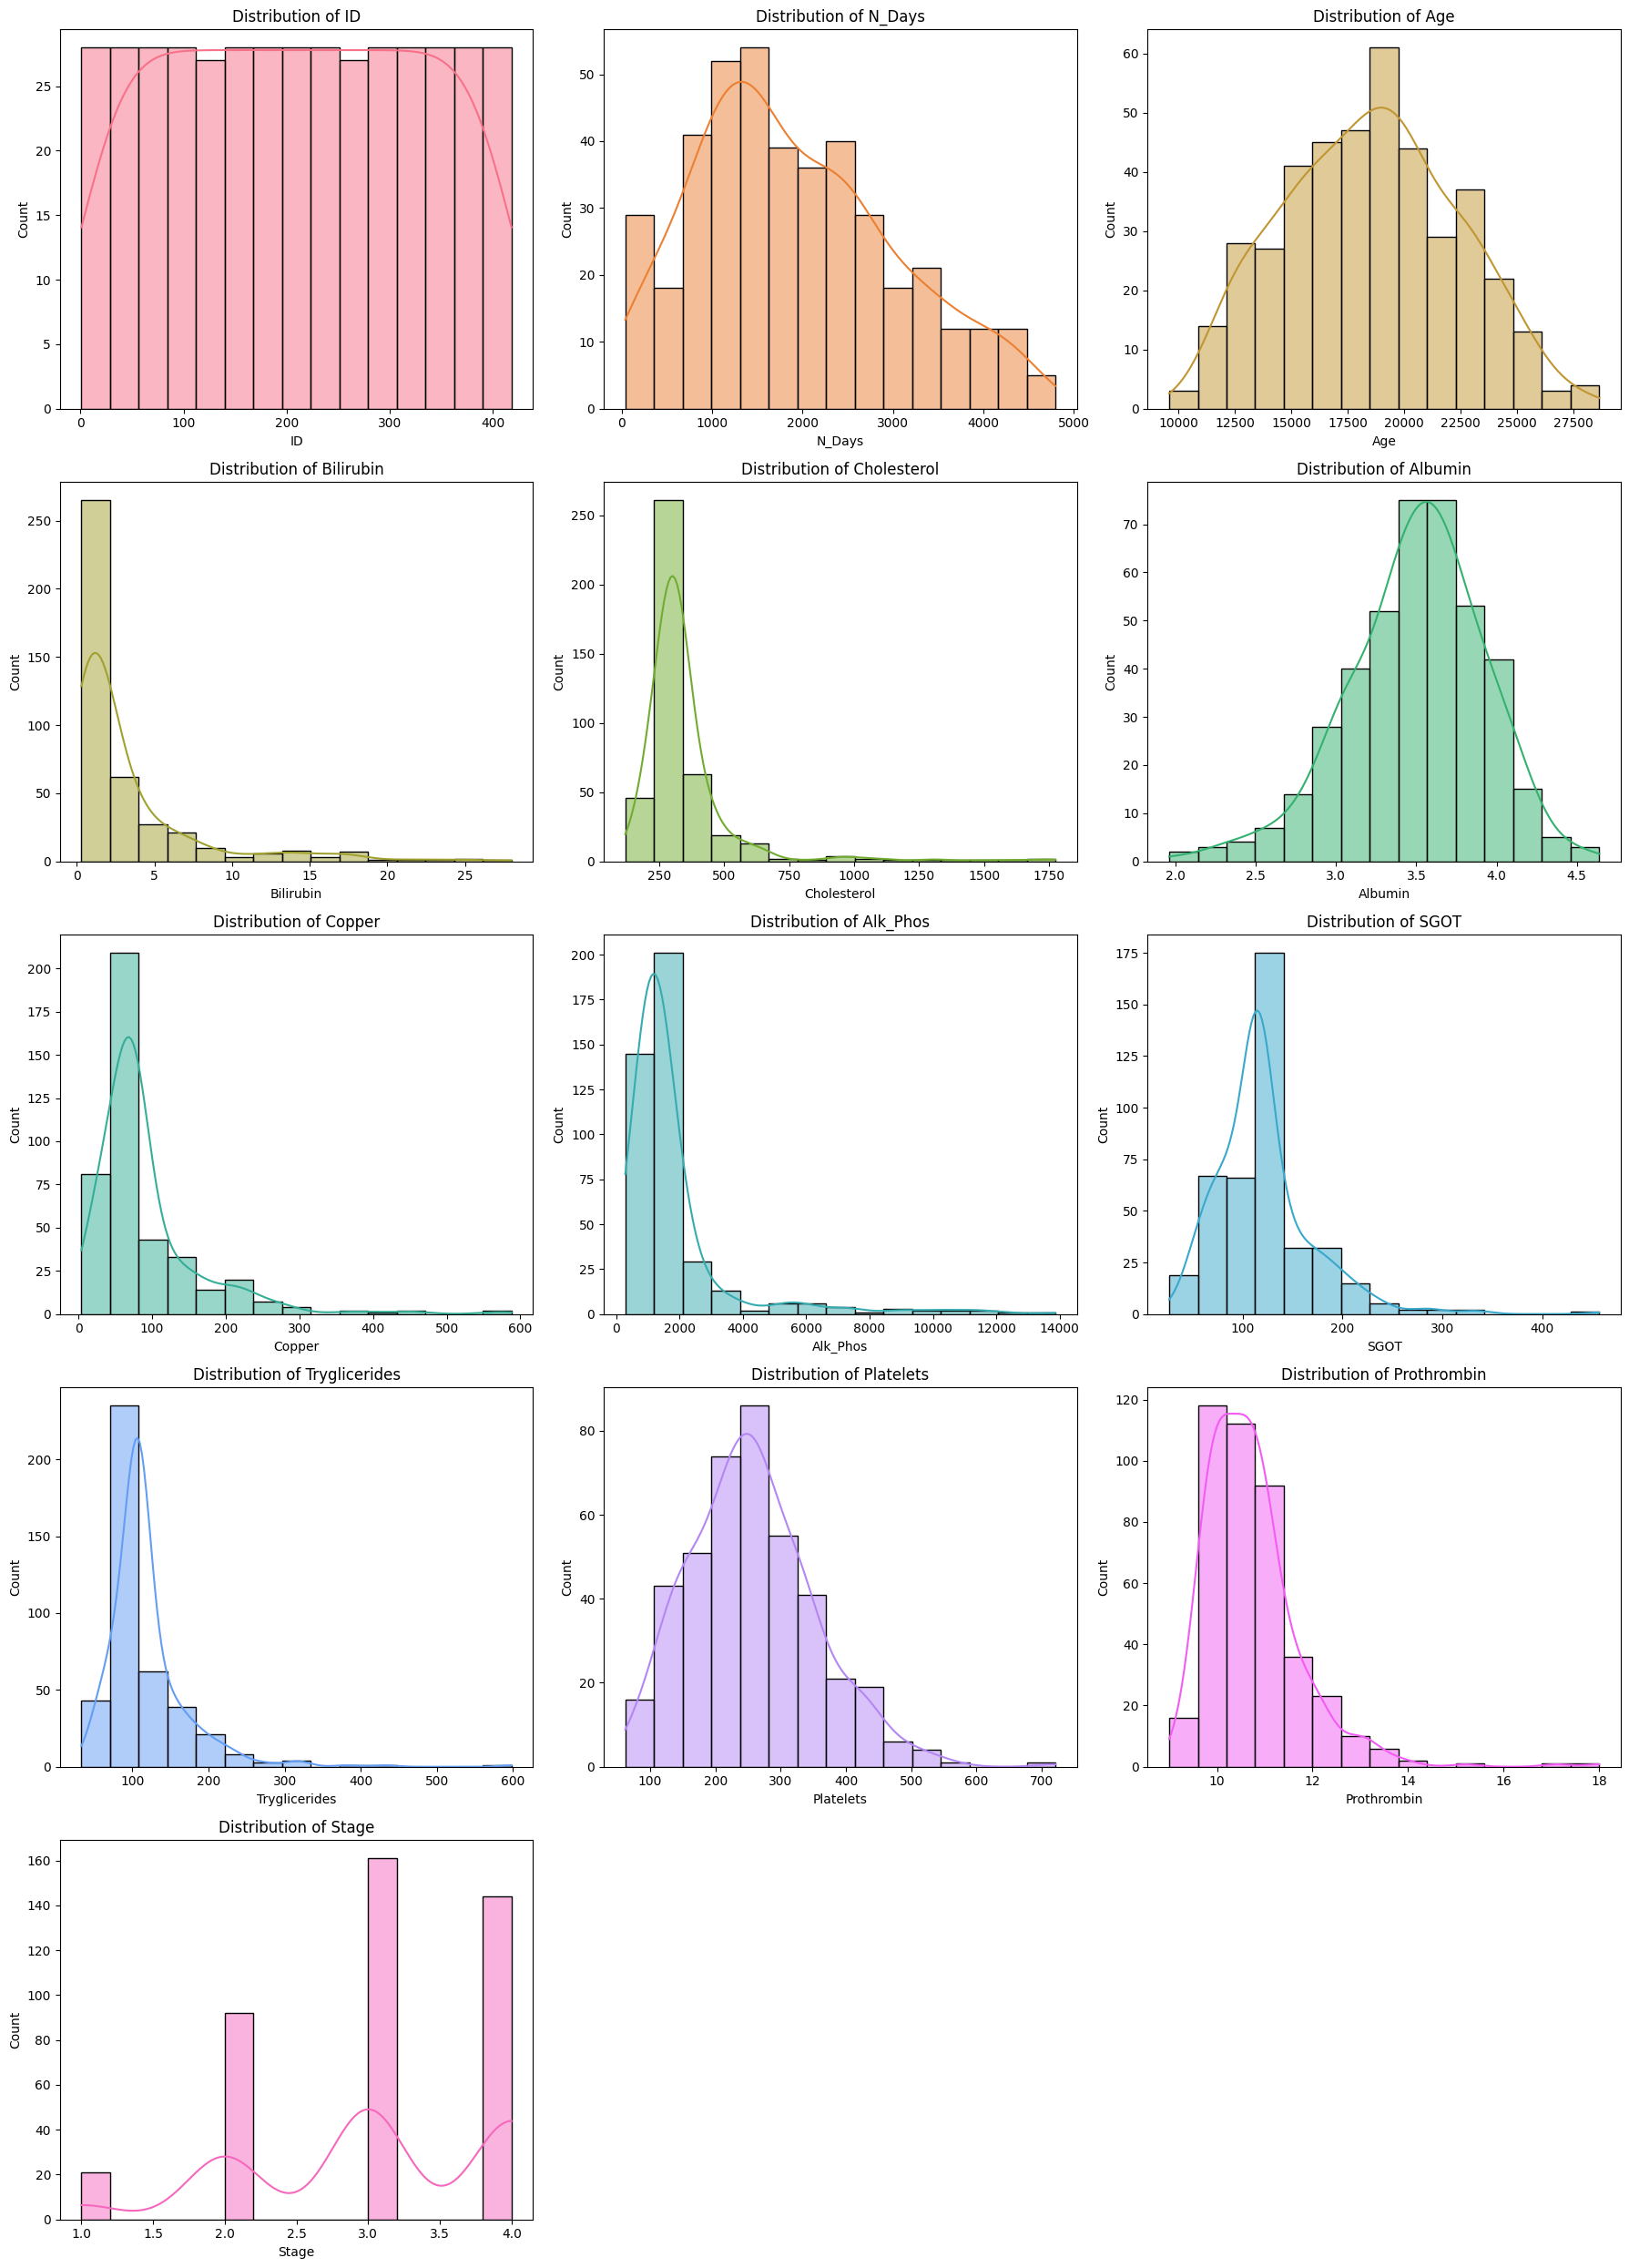

In [188]:
# Define a custom color palette
colors = sns.color_palette("husl", len(numeric_cols))  # You can also try "Set2", "pastel", etc.

# Set number of plots per row
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

# Plot each numeric column
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data[col], kde=True, color=colors[i], bins=15)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


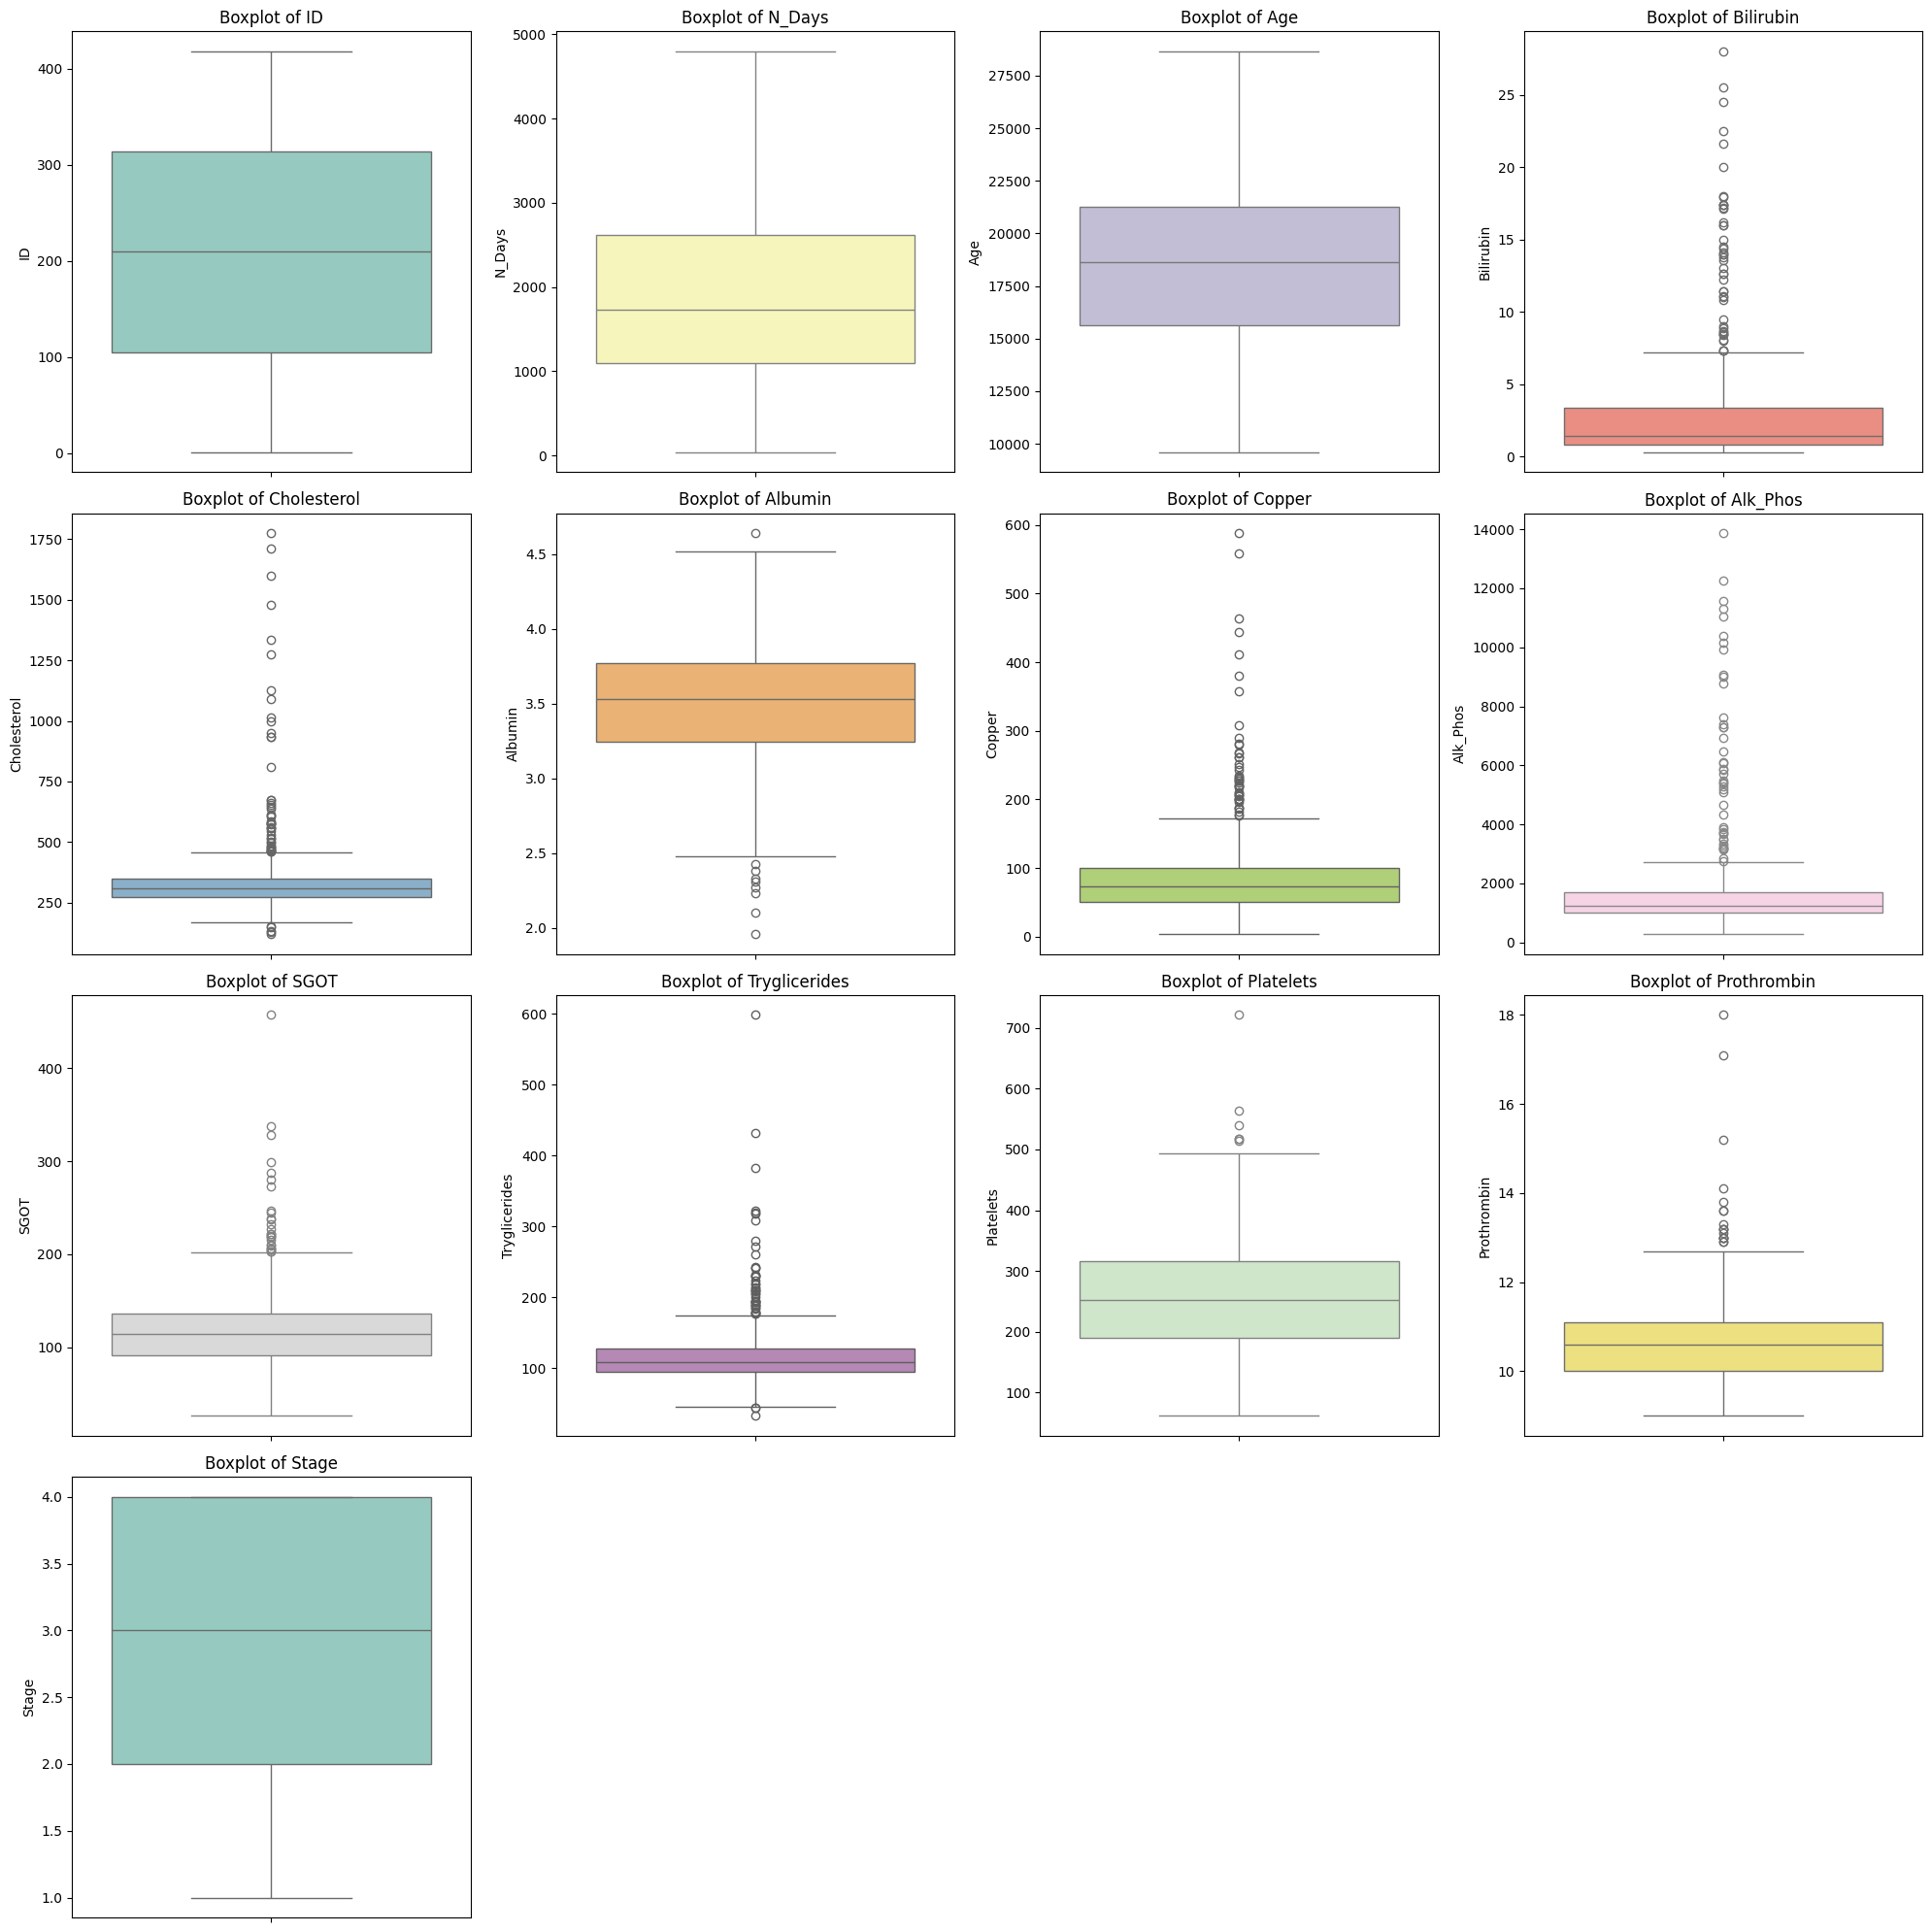

In [189]:
# Define a color palette
colors = sns.color_palette("Set3", len(numeric_cols))  # Options: "pastel", "husl", "Set2"

# Set up plotting area with 4 subplots per row
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # Ceiling division

plt.figure(figsize=(20, 5 * n_rows))  # Adjust figure width for 4 plots per row

# Plot each numeric column as a boxplot
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=data, y=col, color=colors[i])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


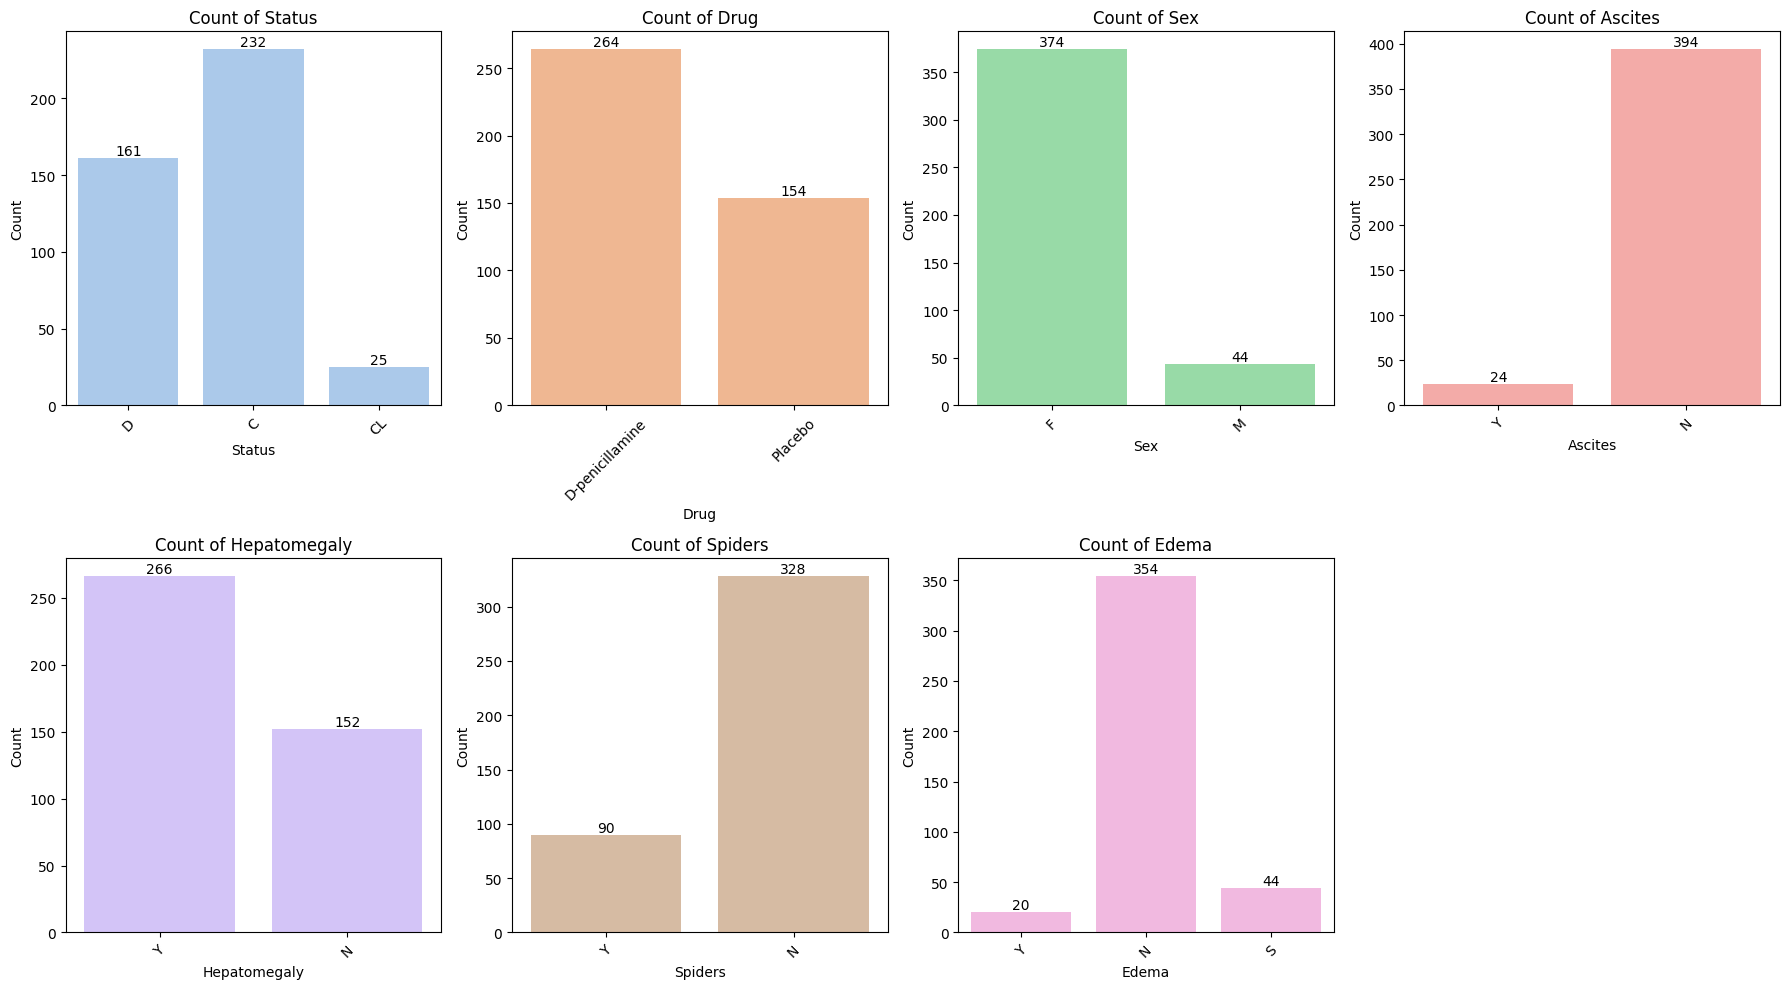

In [190]:
# Define a color palette
colors = sns.color_palette("pastel", len(categorical_cols))  # You can also try: "Set2", "husl", etc.

# Plot layout
n_cols = 4  # Number of plots per row
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

# Create bar plots for each categorical variable
for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    ax = sns.countplot(data=data, x=col, color=colors[i])
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    # Add count labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


* Many features are not normally distributed, so scaling (e.g., RobustScaler or MinMaxScaler) and log transformation might be useful before training.

* Target variable imbalance needs to be addressed (e.g., via class weights or oversampling techniques like SMOTE).

* The gender imbalance reflects the real-world nature of the disease but should be considered when interpreting model bias.

* Imputation strategy using mean, median, or mode is appropriate based on skewness and variable types (as justified earlier).

# Data Preprocessing

In [191]:
import statsmodels.api as SM  # Importing Statsmodels API and aliasing it as 'SM'
from sklearn.compose import ColumnTransformer  # For applying different preprocessing steps to numerical and categorical columns separately
from sklearn.pipeline import Pipeline  # For creating a streamlined workflow by chaining preprocessing and modeling steps together
from sklearn.linear_model import LogisticRegression  # Logistic Regression model for binary or multiclass classification
from sklearn.ensemble import RandomForestClassifier  # Random Forest model for classification (uses multiple decision trees to improve accuracy)
from sklearn.svm import SVC  # Support Vector Classifier (SVM) for classification tasks, effective for high-dimensional data
from sklearn.model_selection import GridSearchCV  # For hyperparameter tuning using grid search to find the best combination of parameters
from sklearn.model_selection import StratifiedKFold  # For cross-validation ensuring class distribution is preserved in each fold
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


Data Preparation for modeling

In [192]:
# Drop ID column
data.drop(columns=['ID'], inplace=True)
data.head()


,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.500,261.000,2.600,156.000,1718.000,137.950,172.000,190.000,12.200,4.000
1,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.100,302.000,4.140,54.000,7394.800,113.520,88.000,221.000,10.600,3.000
2,1012,D,D-penicillamine,25594,M,N,N,N,S,1.400,176.000,3.480,210.000,516.000,96.100,55.000,151.000,12.000,4.000
3,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.800,244.000,2.540,64.000,6121.800,60.630,92.000,183.000,10.300,4.000
4,1504,CL,Placebo,13918,F,N,Y,Y,N,3.400,279.000,3.530,143.000,671.000,113.150,72.000,136.000,10.900,3.000


In [193]:
# Map target variable to numeric
status_mapping = {'D': 0, 'C': 1, 'CL': 2}
data['Status'] = data['Status'].map(status_mapping)
data.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,0,D-penicillamine,21464,F,Y,Y,Y,Y,14.500,261.000,2.600,156.000,1718.000,137.950,172.000,190.000,12.200,4.000
1,4500,1,D-penicillamine,20617,F,N,Y,Y,N,1.100,302.000,4.140,54.000,7394.800,113.520,88.000,221.000,10.600,3.000
2,1012,0,D-penicillamine,25594,M,N,N,N,S,1.400,176.000,3.480,210.000,516.000,96.100,55.000,151.000,12.000,4.000
3,1925,0,D-penicillamine,19994,F,N,Y,Y,S,1.800,244.000,2.540,64.000,6121.800,60.630,92.000,183.000,10.300,4.000
4,1504,2,Placebo,13918,F,N,Y,Y,N,3.400,279.000,3.530,143.000,671.000,113.150,72.000,136.000,10.900,3.000


In [194]:
df = data.copy()

# Encode categorical variables
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

df

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,0,0,21464,0,1,1,1,2,14.500,261.000,2.600,156.000,1718.000,137.950,172.000,190.000,12.200,4.000
1,4500,1,0,20617,0,0,1,1,0,1.100,302.000,4.140,54.000,7394.800,113.520,88.000,221.000,10.600,3.000
2,1012,0,0,25594,1,0,0,0,1,1.400,176.000,3.480,210.000,516.000,96.100,55.000,151.000,12.000,4.000
3,1925,0,0,19994,0,0,1,1,1,1.800,244.000,2.540,64.000,6121.800,60.630,92.000,183.000,10.300,4.000
4,1504,2,1,13918,0,0,1,1,0,3.400,279.000,3.530,143.000,671.000,113.150,72.000,136.000,10.900,3.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,681,0,0,24472,0,0,1,0,0,1.200,309.500,2.960,73.000,1259.000,114.700,108.000,174.000,10.900,3.000
414,1103,1,0,14245,0,0,1,0,0,0.900,309.500,3.830,73.000,1259.000,114.700,108.000,180.000,11.200,4.000
415,1055,1,0,20819,0,0,1,0,0,1.600,309.500,3.420,73.000,1259.000,114.700,108.000,143.000,9.900,3.000
416,691,1,0,21185,0,0,1,0,0,0.800,309.500,3.750,73.000,1259.000,114.700,108.000,269.000,10.400,3.000


In [195]:
# Features and target
X = df.drop(columns=["Status"])
y = df["Status"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [196]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Shape of Training set : ", y_train.shape)
print("Shape of test set : ", y_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (334, 18)
Shape of test set :  (84, 18)
Shape of Training set :  (334,)
Shape of test set :  (84,)
Percentage of classes in training set:
Status
1   0.554
0   0.386
2   0.060
Name: proportion, dtype: float64
Percentage of classes in test set:
Status
1   0.560
0   0.381
2   0.060
Name: proportion, dtype: float64


In [197]:
# Checking the Label Distribution in Training Set
label_distribution = y_train.value_counts(normalize=True) * 100
print("Label Distribution in Training Set:")
print(label_distribution.sort_index())

Label Distribution in Training Set:
Status
0   38.623
1   55.389
2    5.988
Name: proportion, dtype: float64


**Label 2 (CL) is significantly underrepresented**, making up only ~6% of the training data.

# Model Building

**Random Forest** - Chosen for its robustness to overfitting and ability to handle non-linear relationships and feature interactions without much preprocessing.

**Logistic Regression** - Selected as a strong baseline model for multi-class classification, offering interpretability and efficiency on linearly separable data.

**Support Vector Machine** - Used for its capability to model complex decision boundaries with kernel tricks, especially effective in high-dimensional spaces.

In [198]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [199]:
# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}

In [200]:
# Train and cross-validate
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    print(f"\n{name} - Mean Accuracy: {scores.mean():.4f}, Std: {scores.std():.4f}")

    # Fit and evaluate on test set
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Random Forest - Mean Accuracy: 0.7783, Std: 0.0369
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.62      0.67        32
           1       0.71      0.85      0.78        47
           2       0.00      0.00      0.00         5

    accuracy                           0.71        84
   macro avg       0.48      0.49      0.48        84
weighted avg       0.67      0.71      0.69        84

Confusion Matrix:
[[20 12  0]
 [ 7 40  0]
 [ 1  4  0]]

Logistic Regression - Mean Accuracy: 0.7335, Std: 0.0608
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.72      0.77        32
           1       0.80      0.94      0.86        47
           2       0.00      0.00      0.00         5

    accuracy                           0.80        84
   macro avg       0.54      0.55      0.54        84
weighted avg       0.76      0.80      0.77        84

Confusion Matrix:
[[23  8  


Model: Random Forest
Cross-Validated Accuracy: 0.7783 ± 0.0369

📊 Classification Report:


,precision,recall,f1-score,support
0,0.714,0.625,0.667,32.000
1,0.714,0.851,0.777,47.000
2,0.000,0.000,0.000,5.000
accuracy,0.714,0.714,0.714,0.714
macro avg,0.476,0.492,0.481,84.000
weighted avg,0.672,0.714,0.689,84.000



🔷 Confusion Matrix:


,Predicted: Death (0),Predicted: Censored (1),Predicted: Liver Tx (2)
Actual: Death (0),20,12,0
Actual: Censored (1),7,40,0
Actual: Liver Tx (2),1,4,0


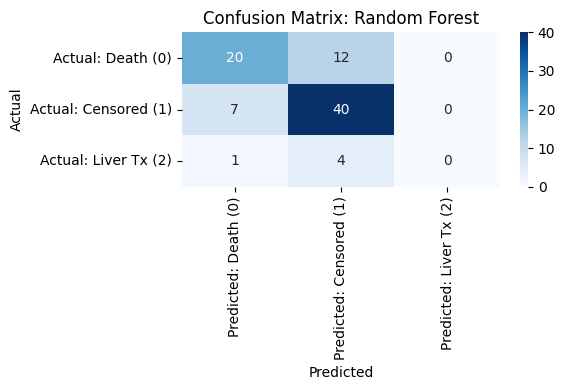


Model: Logistic Regression
Cross-Validated Accuracy: 0.7335 ± 0.0608

📊 Classification Report:


,precision,recall,f1-score,support
0,0.821,0.719,0.767,32.000
1,0.800,0.936,0.863,47.000
2,0.000,0.000,0.000,5.000
accuracy,0.798,0.798,0.798,0.798
macro avg,0.540,0.552,0.543,84.000
weighted avg,0.761,0.798,0.775,84.000



🔷 Confusion Matrix:


,Predicted: Death (0),Predicted: Censored (1),Predicted: Liver Tx (2)
Actual: Death (0),23,8,1
Actual: Censored (1),3,44,0
Actual: Liver Tx (2),2,3,0


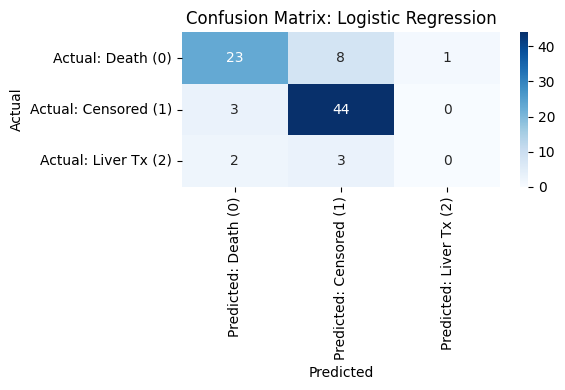


Model: Support Vector Machine
Cross-Validated Accuracy: 0.7455 ± 0.0869

📊 Classification Report:


,precision,recall,f1-score,support
0,0.741,0.625,0.678,32.000
1,0.719,0.872,0.788,47.000
2,0.000,0.000,0.000,5.000
accuracy,0.726,0.726,0.726,0.726
macro avg,0.487,0.499,0.489,84.000
weighted avg,0.685,0.726,0.699,84.000



🔷 Confusion Matrix:


,Predicted: Death (0),Predicted: Censored (1),Predicted: Liver Tx (2)
Actual: Death (0),20,12,0
Actual: Censored (1),6,41,0
Actual: Liver Tx (2),1,4,0


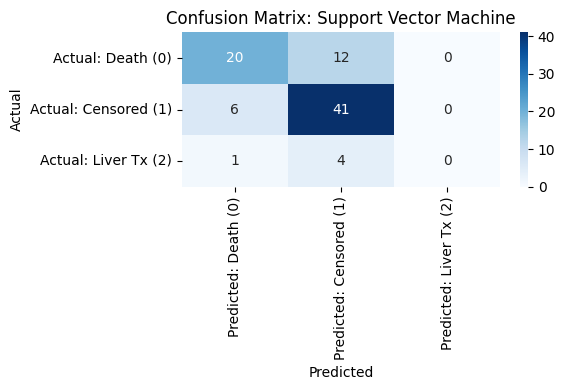

In [201]:
# Train and evaluate models with formatted output
for name, model in models.items():
    print(f"\n{'='*40}\nModel: {name}\n{'='*40}")

    # Cross-validation score
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    print(f"Cross-Validated Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

    # Train on full training data and predict
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Classification Report
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df = report_df.round(3)
    print("\n📊 Classification Report:")
    display(report_df)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual: Death (0)", "Actual: Censored (1)", "Actual: Liver Tx (2)"],
        columns=["Predicted: Death (0)", "Predicted: Censored (1)", "Predicted: Liver Tx (2)"]
    )
    print("\n🔷 Confusion Matrix:")
    display(cm_df)

    # Optional: Visual confusion matrix plot
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues")
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


**Observations**

* Logistic Regression correctly classified 23 Deaths and 44 Censored cases, with minimal misclassifications compared to others. Random Forest and SVM showed similar misclassification patterns but struggled slightly more with Censored predictions.

* Random Forest may be chosen if overall accuracy is the priority.

# Dealing with imbalance Training data

**SMOTE** or class-weight adjustments can be applied to handle the Liver Transplant class imbalance.

**SMOTE** helps prevent the model from ignoring important but underrepresented outcomes, leading to more accurate and fair predictions across all classes

In [202]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Balanced class distribution:\n", pd.Series(y_train_bal).value_counts())

Balanced class distribution:
 Status
0    185
1    185
2    185
Name: count, dtype: int64


# Hyperparameter Tuning

In [203]:
# ------------------------
# Logistic Regression
# ------------------------
logistic_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}
log_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                        logistic_params, cv=5, scoring='accuracy')
log_grid.fit(X_train_bal, y_train_bal)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [204]:
# ------------------------
# Random Forest
# ------------------------
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train_bal, y_train_bal)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [205]:
# ------------------------
# SVM
# ------------------------
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear']
}
svm_grid = GridSearchCV(SVC(random_state=42),
                        svm_params, cv=5, scoring='accuracy')
svm_grid.fit(X_train_bal, y_train_bal)

GridSearchCV(cv=5, estimator=SVC(random_state=42),
             param_grid={'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']},
             scoring='accuracy')

In [206]:
# Best models
best_models = {
    "Logistic Regression": log_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
}

In [207]:
# Evaluate all on test set
for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name} (Tuned)")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression (Tuned)
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.79      0.66      0.72        47
           2       0.14      0.40      0.21         5

    accuracy                           0.68        84
   macro avg       0.57      0.60      0.56        84
weighted avg       0.75      0.68      0.71        84

Confusion Matrix:
[[24  6  2]
 [ 6 31 10]
 [ 1  2  2]]

Random Forest (Tuned)
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.66      0.69        32
           1       0.82      0.85      0.83        47
           2       0.00      0.00      0.00         5

    accuracy                           0.73        84
   macro avg       0.51      0.50      0.51        84
weighted avg       0.73      0.73      0.73        84

Confusion Matrix:
[[21  6  5]
 [ 6 40  1]
 [ 2  3  0]]

SVM (Tuned)
Classification Re


Logistic Regression (Tuned Model Evaluation)

📊 Classification Report:


,precision,recall,f1-score,support
0,0.774,0.750,0.762,32.000
1,0.795,0.660,0.721,47.000
2,0.143,0.400,0.211,5.000
accuracy,0.679,0.679,0.679,0.679
macro avg,0.571,0.603,0.564,84.000
weighted avg,0.748,0.679,0.706,84.000



🔷 Confusion Matrix:


,Predicted: Death (0),Predicted: Censored (1),Predicted: Liver Tx (2)
Actual: Death (0),24,6,2
Actual: Censored (1),6,31,10
Actual: Liver Tx (2),1,2,2


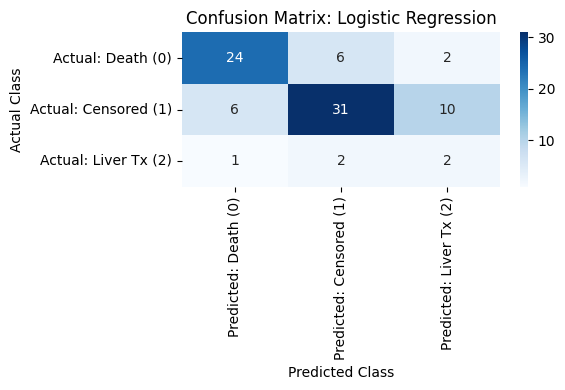


Random Forest (Tuned Model Evaluation)

📊 Classification Report:


,precision,recall,f1-score,support
0,0.724,0.656,0.689,32.000
1,0.816,0.851,0.833,47.000
2,0.000,0.000,0.000,5.000
accuracy,0.726,0.726,0.726,0.726
macro avg,0.513,0.502,0.507,84.000
weighted avg,0.733,0.726,0.729,84.000



🔷 Confusion Matrix:


,Predicted: Death (0),Predicted: Censored (1),Predicted: Liver Tx (2)
Actual: Death (0),21,6,5
Actual: Censored (1),6,40,1
Actual: Liver Tx (2),2,3,0


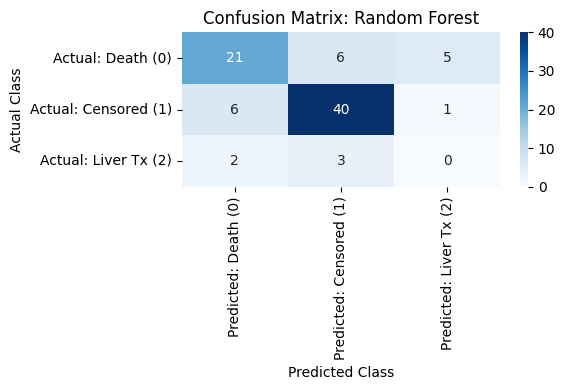


SVM (Tuned Model Evaluation)

📊 Classification Report:


,precision,recall,f1-score,support
0,0.714,0.625,0.667,32.000
1,0.712,0.787,0.747,47.000
2,0.000,0.000,0.000,5.000
accuracy,0.679,0.679,0.679,0.679
macro avg,0.475,0.471,0.471,84.000
weighted avg,0.670,0.679,0.672,84.000



🔷 Confusion Matrix:


,Predicted: Death (0),Predicted: Censored (1),Predicted: Liver Tx (2)
Actual: Death (0),20,11,1
Actual: Censored (1),7,37,3
Actual: Liver Tx (2),1,4,0


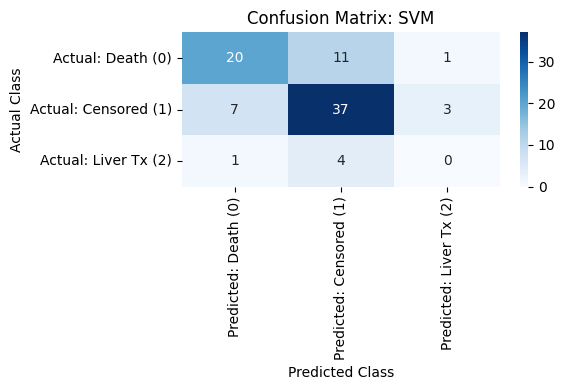

In [208]:
# Evaluate all tuned models on the test set with formatted output
for name, model in best_models.items():
    print(f"\n{'='*45}\n{name} (Tuned Model Evaluation)\n{'='*45}")

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Classification Report as DataFrame
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(3)

    print("\n📊 Classification Report:")
    display(report_df)

    # Confusion Matrix as DataFrame
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual: Death (0)", "Actual: Censored (1)", "Actual: Liver Tx (2)"],
        columns=["Predicted: Death (0)", "Predicted: Censored (1)", "Predicted: Liver Tx (2)"]
    )
    print("\n🔷 Confusion Matrix:")
    display(cm_df)

    # Optional: Plot confusion matrix heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues")
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.show()


**Observations**

* Logistic Regression (Tuned): Better balance across classes, improved predictions for Liver Tx (2 correct vs 0 before tuning).

* Random Forest (Tuned): High Censored classification accuracy but significant misclassification of Death as Liver Tx.

* Overall, Random Forest is recommended for deployment due to its balanced performance, whereas Logistic Regression is preferable for clinical decision-making where early Liver Transplant detection is prioritized. Further improvements should focus on class imbalance handling (SMOTE, class weights) and advanced ensemble methods (XGBoost, LightGBM)

# Feature Importance

In [210]:
# Scale numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Random Forest Importance:

Measures how often a feature is used to split a node and how much it reduces impurity (Gini index). Features with higher importance contribute more to accurate predictions. Non-linear interactions and feature combinations are considered.

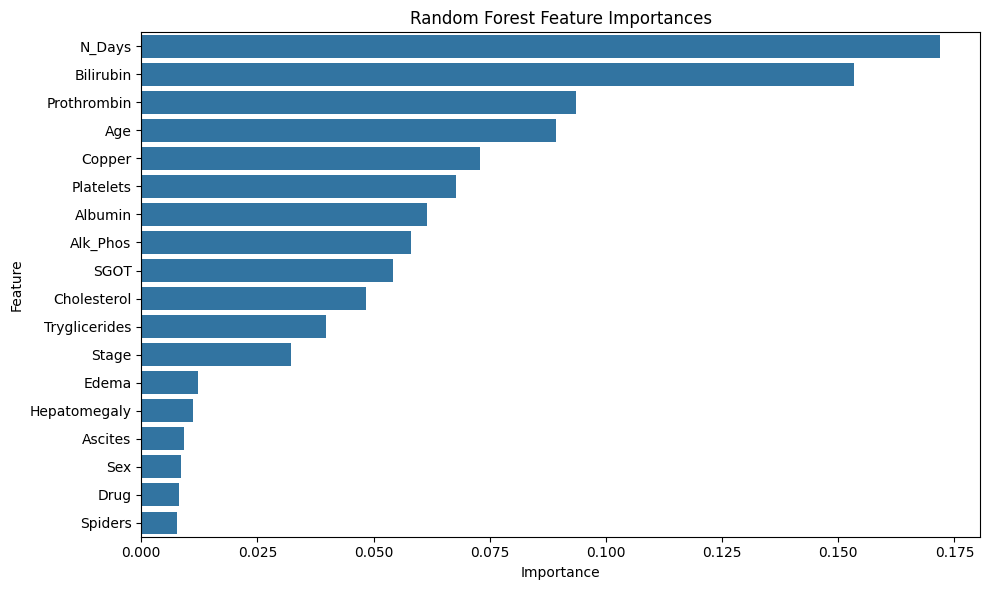

In [211]:
# 1. Model-Based Feature Importance (Random Forest)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_scaled, y)

importances = rf_model.feature_importances_
features = X.columns
rf_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df)
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()


## ANOVA F-Test:

Measures variance between groups (classes) versus variance within groups. Higher F-score = feature values are statistically different across survival classes. Works best for numerical features with normally distributed values.

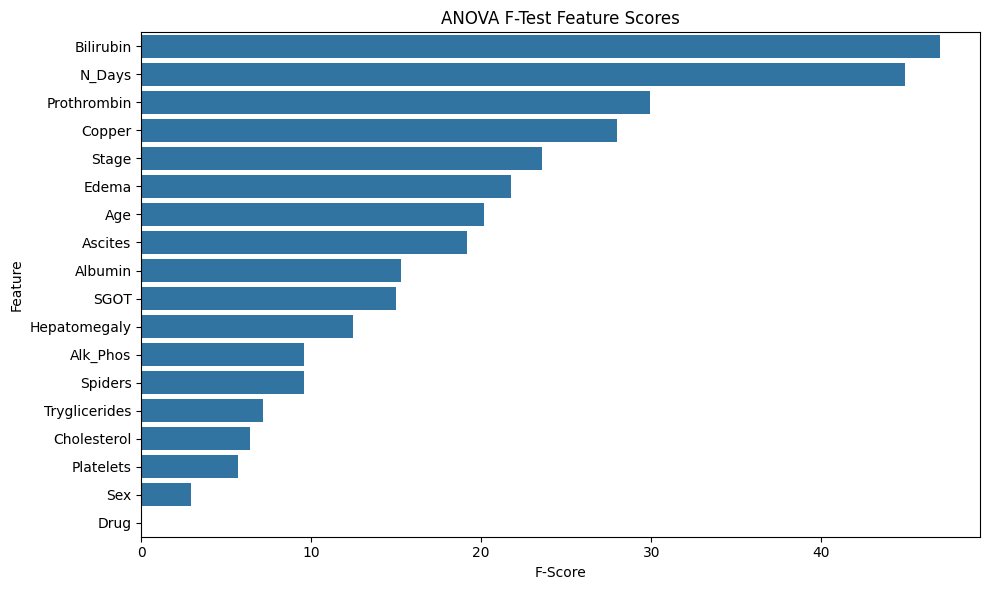

In [214]:
# Statistical Test: ANOVA F-test

from sklearn.feature_selection import SelectKBest, chi2, f_classif
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X_scaled, y)
anova_scores = anova_selector.scores_

anova_df = pd.DataFrame({'Feature': features, 'F-Score': anova_scores})
anova_df = anova_df.sort_values(by='F-Score', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='F-Score', y='Feature', data=anova_df)
plt.title("ANOVA F-Test Feature Scores")
plt.tight_layout()
plt.show()

**Observations**

* Bilirubin, Prothrombin, and N_Days appear among the top predictors of patient survival status in both methods.

* These features likely have strong relationships with liver function deterioration and survival outcome, which justifies their importance both statistically and in medical context